# Plotting the baseline, the late bubbles and the 3 bubble sequence.

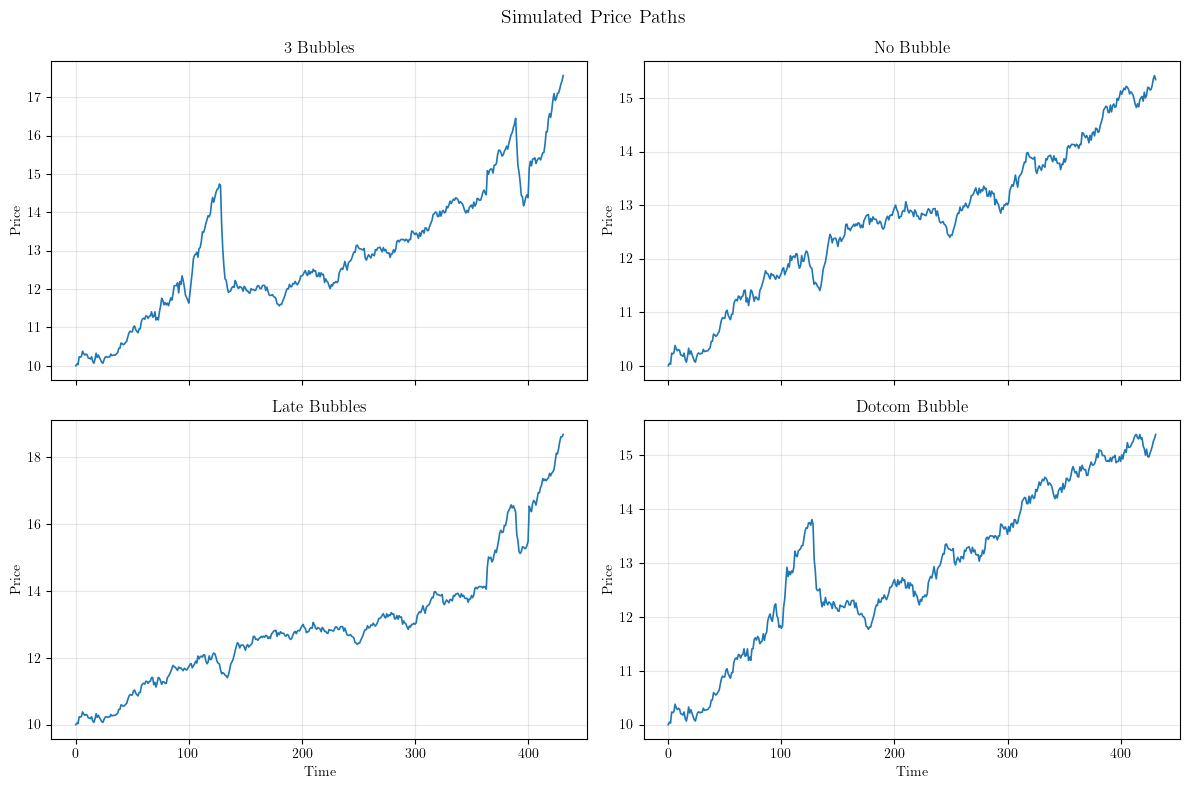

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# If notebook is in simulation/, use "data". If run from repo root, use "simulation/data".
data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("simulation/data")

files = [
    ("P_3bubbles.csv", "3 Bubbles"),
    ("P_nobubble.csv", "No Bubble"),
    ("P_latebubbles.csv", "Late Bubbles"),
    ("P_dotcom.csv", "Dotcom Bubble"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for ax, (fname, title) in zip(axes, files):
    df = pd.read_csv(data_dir / fname)
    # Use first numeric column (works even if column names differ)
    series = df.select_dtypes(include="number").iloc[:, 0]
    ax.plot(series.values, lw=1.2)
    ax.set_title(title)
    ax.set_ylabel("Price")
    ax.grid(alpha=0.3)

for ax in axes[2:]:
    ax.set_xlabel("Time")

fig.suptitle("Simulated Price Paths", fontsize=14)
fig.tight_layout()
plt.show()